In [2]:
import scanpy as sc
import numpy as np
import seaborn as sns

In [3]:
adata=sc.read_h5ad("brain_small.h5ad")
adata.layers['raw']=adata.X.copy()

/home/whalstj1/2025-bioinformatics/202255180/week11/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


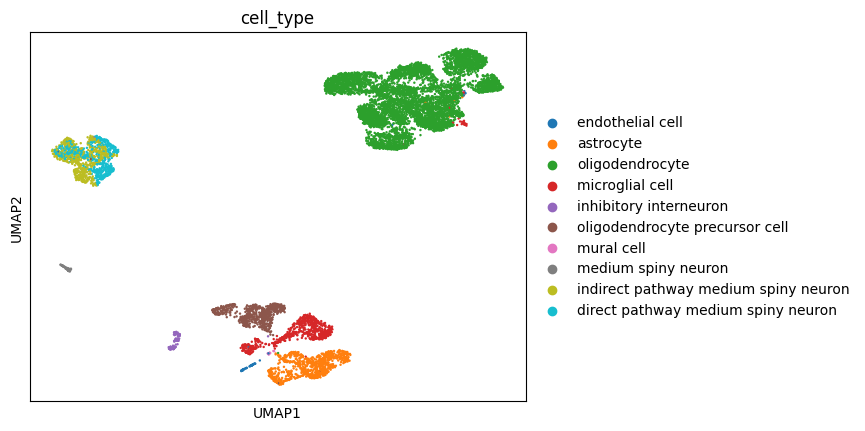

In [4]:
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)
sc.pp.pca(adata)
sc.pp.neighbors(adata)
sc.tl.umap(adata)
sc.pl.umap(adata, color='cell_type')

In [6]:
cell_types = adata.obs['cell_type'].cat.categories
sig=np.zeros((len(cell_types), adata.shape[1]))
for i, ct in enumerate(cell_types):
    idx=adata.obs['cell_type']==ct
    sig[i]= adata.layers['raw'][idx.values].sum(axis=0)
    sig[i] /= sig[i].max()

In [7]:
import numpy as np
v=np.asarray(adata.layers['raw'].sum(axis=0)).ravel()
v=v/v.max()

Generalized Linear Model

In [8]:
import statsmodels.api as sm

X=sig.T
y=v

model=sm.GLM(y,X)
result=model.fit()

print(result.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                      y   No. Observations:                30818
Model:                            GLM   Df Residuals:                    30808
Model Family:                Gaussian   Df Model:                            9
Link Function:               Identity   Scale:                      1.2158e-35
Method:                          IRLS   Log-Likelihood:             1.1508e+06
Date:                Tue, 11 Nov 2025   Deviance:                   6.6532e-30
Time:                        17:01:57   Pearson chi2:                 6.65e-30
No. Iterations:                     3   Pseudo R-squ. (CS):              1.000
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
x1             0.0026    7.7e-18   3.32e+14      0.0

/home/whalstj1/2025-bioinformatics/202255180/week11/.venv/lib/python3.13/site-packages/statsmodels/genmod/generalized_linear_model.py:1342: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnings.warn(msg, category=PerfectSeparationWarning)
/home/whalstj1/2025-bioinformatics/202255180/week11/.venv/lib/python3.13/site-packages/statsmodels/genmod/generalized_linear_model.py:1342: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnings.warn(msg, category=PerfectSeparationWarning)
/home/whalstj1/2025-bioinformatics/202255180/week11/.venv/lib/python3.13/site-packages/statsmodels/genmod/generalized_linear_model.py:1342: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnings.warn(msg, category=PerfectSeparationWarning)


In [9]:
weights=result.params/max(result.params)

<Axes: xlabel='None'>

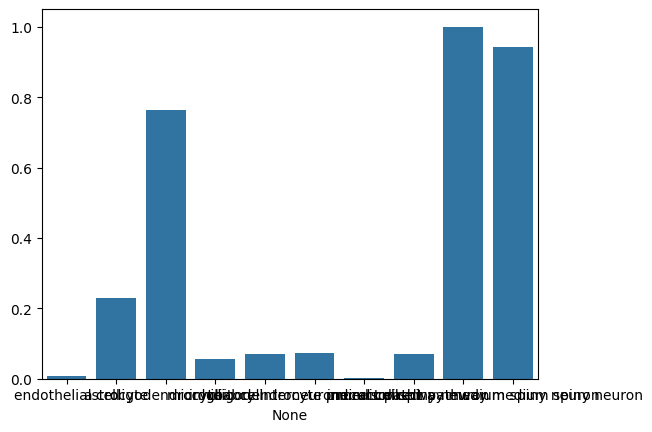

In [10]:
sns.barplot(x=cell_types, y=weights)

CIBERSORT

In [11]:
from sklearn.svm import NuSVR

X=sig.T
y=v

clf=NuSVR(nu=0.25, kernel='linear')
clf.fit(X,y)

,nu,0.25
,C,1.0
,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,tol,0.001
,cache_size,200
,verbose,False
,max_iter,-1


In [12]:
weights = clf.coef_[0]
weights = weights / weights.max()

<Axes: xlabel='None'>

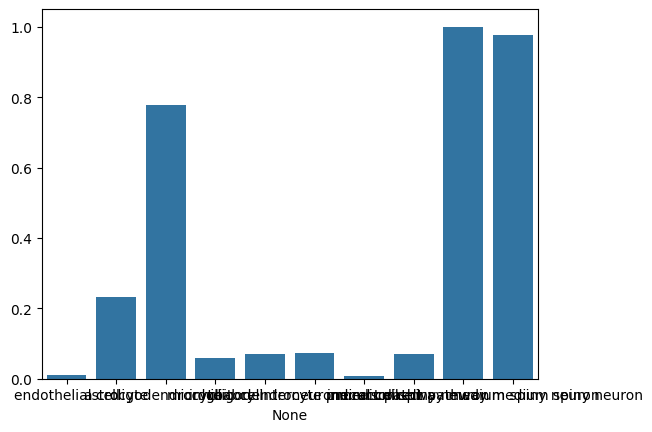

In [13]:
sns.barplot(x=cell_types, y=weights)

True distribution

In [14]:
prop = np.zeros(len(cell_types))
for i, ct in enumerate(cell_types):
    idx = adata.obs['cell_type'] == ct
    prop[i] = idx.sum()

<Axes: xlabel='None'>

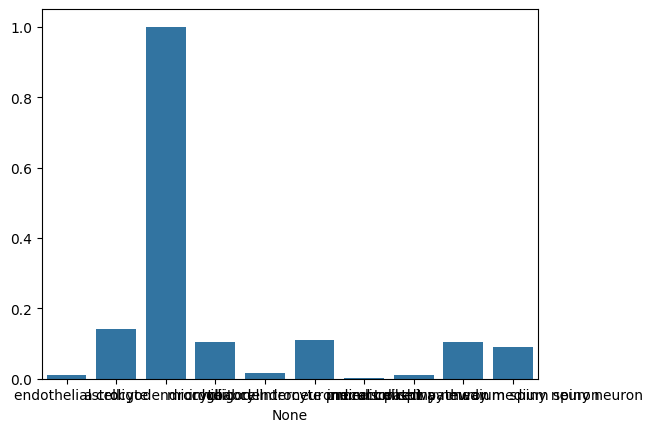

In [15]:
prop = prop / prop.max()
sns.barplot(x=cell_types, y=prop)

NMF

In [16]:
samples=100

np.random.seed(42)
sums=np.zeros((samples,v.shape[0]))
for i in range(samples):
    idx=np.random.choice(adata.layers['raw'].shape[0],1000)
    sums[i]=np.asarray(adata.layers['raw'][idx].sum(axis=0)).ravel()

In [17]:
from sklearn.decomposition import NMF

nmf=NMF(n_components=6, random_state=42,max_iter=10000)
W=nmf.fit_transform(sums)
H=nmf.components_

In [18]:
from scipy.spatial.distance import cdist

dist=cdist(H, sig, metric='cosine')
closet=np.argmin(dist, axis=1)

nmf_labels=[f"{i} (closest: {lbl})" for i, lbl in enumerate(cell_types[closet])]

<Axes: >

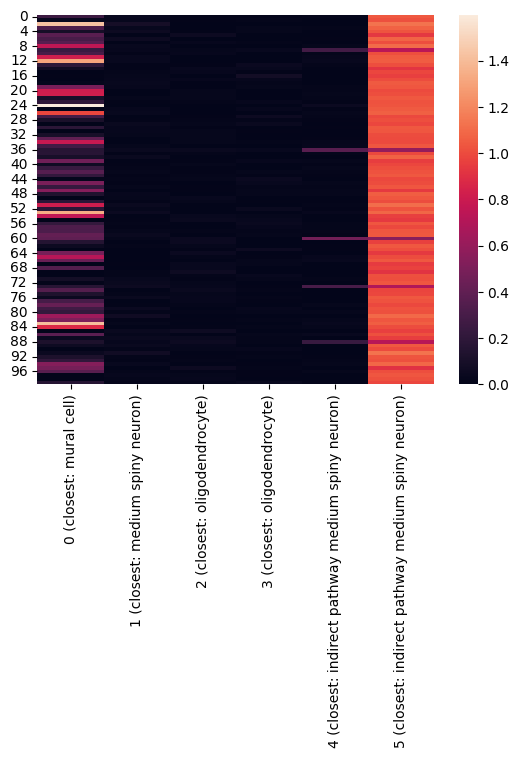

In [19]:
import seaborn as sns
sns.heatmap(W,xticklabels=nmf_labels)

GRN

In [20]:
adata=sc.read_h5ad("brain_small.h5ad")
adata_endo=adata[adata.obs['cell_type']=='endothelial cell']
adata_endo

sc.pp.filter_genes(adata_endo, min_cells=3)
sc.pp.filter_cells(adata_endo, min_genes=200)

sc.pp.log1p(adata_endo)
sc.pp.highly_variable_genes(adata_endo, n_top_genes=500)

adata_endo=adata_endo[:, adata_endo.var.highly_variable]

/home/whalstj1/2025-bioinformatics/202255180/week11/.venv/lib/python3.13/site-packages/scanpy/preprocessing/_simple.py:293: ImplicitModificationWarning: Trying to modify attribute `.var` of view, initializing view as actual.
  adata.var["n_cells"] = number


In [21]:
beta=3
correlation_matrix=np.corrcoef(adata_endo.X.T.todense())
connectivity_matrix=correlation_matrix>0
correlation_matrix=np.abs(correlation_matrix)**beta

In [23]:
k=np.sum(correlation_matrix, axis=1)
tom=np.zeros_like(correlation_matrix)
n=correlation_matrix.shape[0]

for i in range(n):
    for j in range(i+1,n):
        shared=np.sum(correlation_matrix[i,:]*correlation_matrix[j,:])
        tom[i,j]=(shared + correlation_matrix[i,j]) / (min(k[i],k[j]) + 1 - correlation_matrix[i,j])
        tom[j,i]=tom[i,j]
        
disttom=1-tom

In [24]:
from sklearn.cluster import AgglomerativeClustering
clustering=AgglomerativeClustering(linkage='average', n_clusters=30).fit(disttom)

In [25]:
import networkx as nx

nodes=np.where(clustering.labels_==0)[0]
nodes=np.sort(nodes)
connectivity_matrix_0=connectivity_matrix[nodes,:][:,nodes]
G=nx.Graph(connectivity_matrix_0)

G.remove_edges_from(nx.selfloop_edges(G))
G=nx.relabel_nodes(G,dict(enumerate(adata_endo.var.index[nodes])))

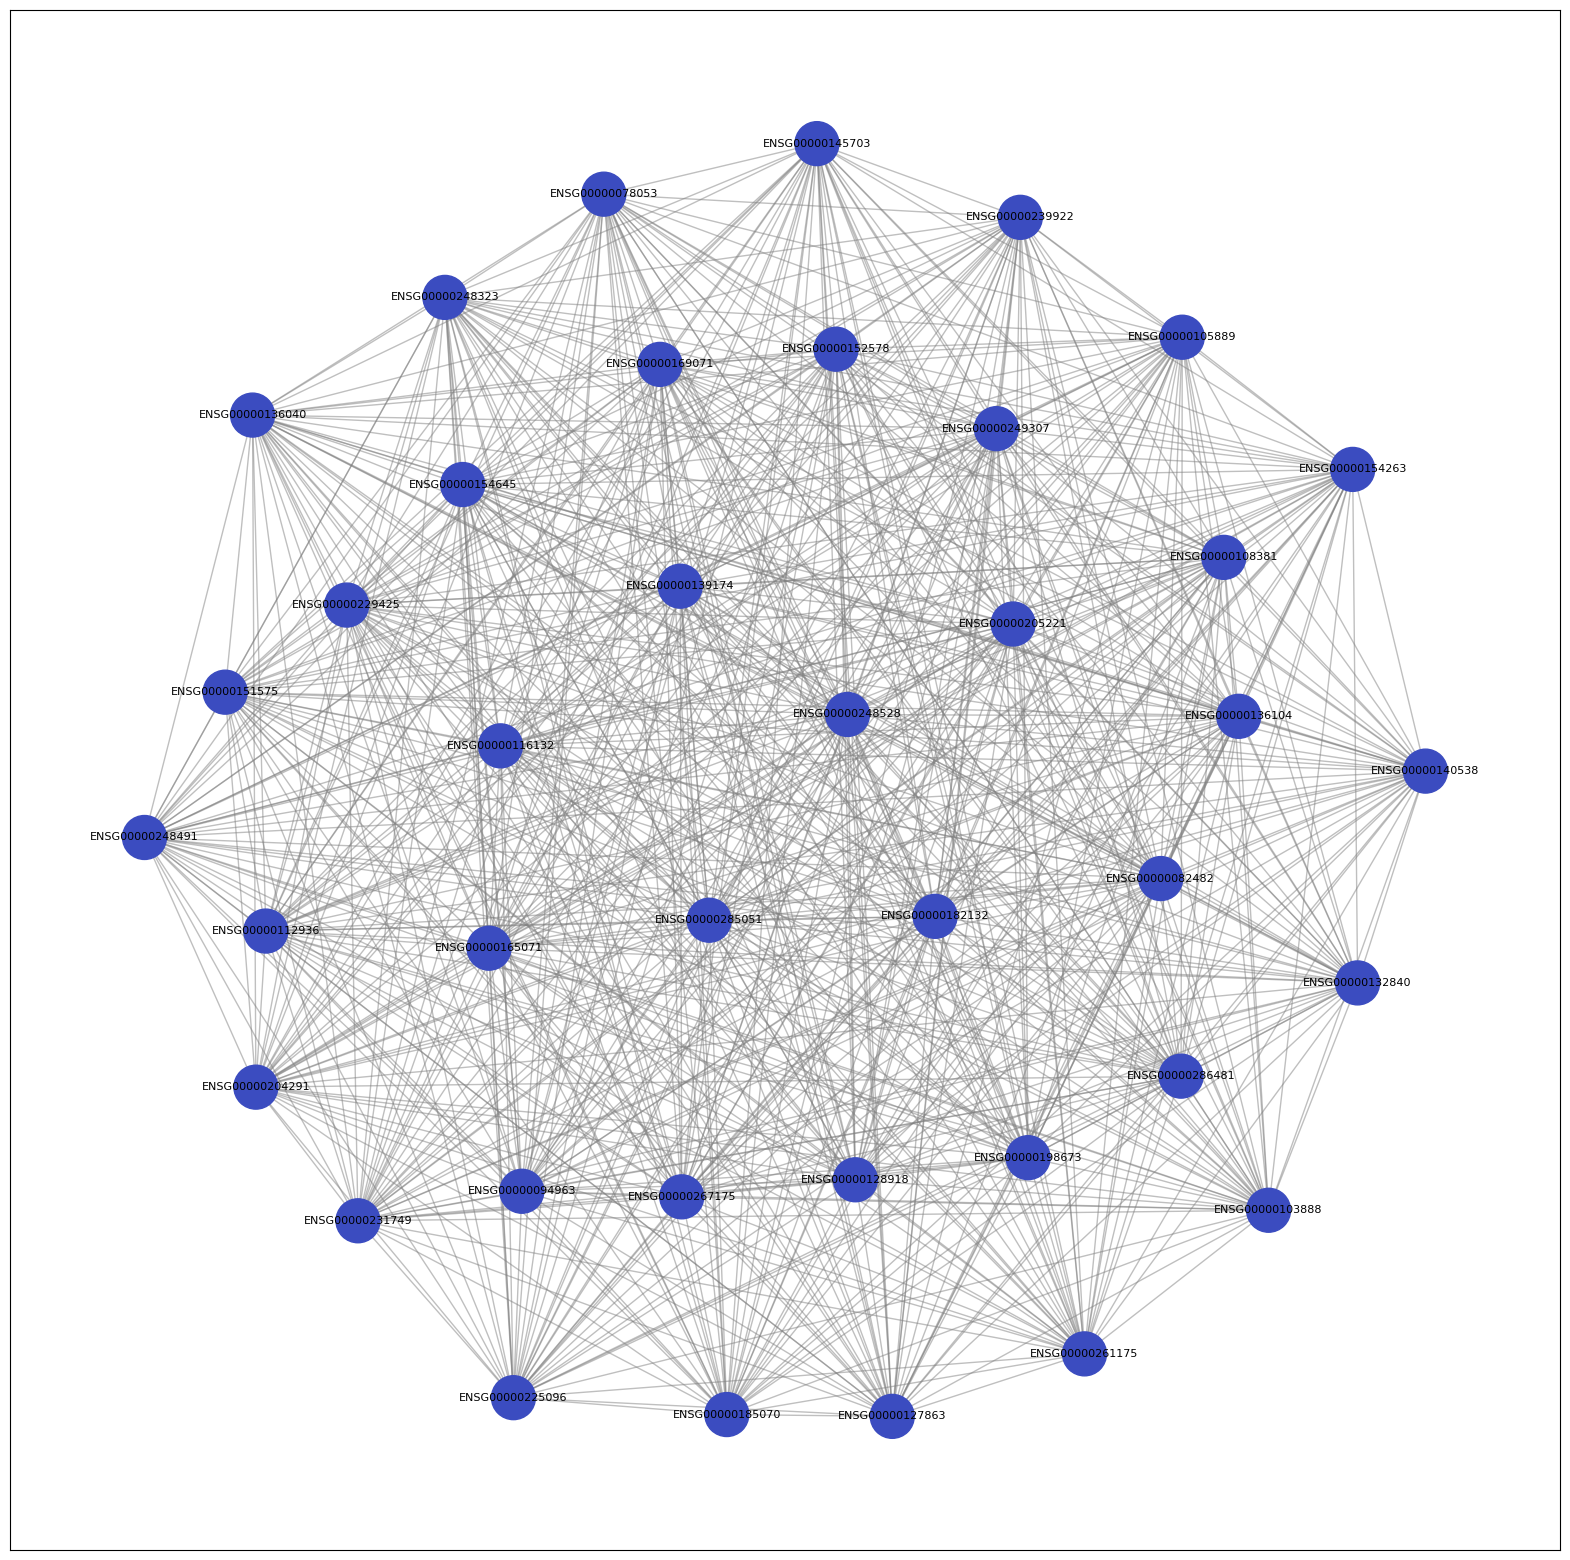

In [26]:
import matplotlib.pyplot as plt

centrality=nx.degree_centrality(G)
pos=nx.spring_layout(G, weight='weight')

plt.figure(figsize=(20,20))
nx.draw_networkx_edges(G,pos,alpha=0.5,edge_color='gray')
nx.draw_networkx_nodes(G,pos,node_size=1000,node_color=[centrality[node] for node in G.nodes],cmap='coolwarm')
nx.draw_networkx_labels(G,pos,font_size=8)

plt.show()